In [6]:
import pandas as pd
from google.colab import files

# 1. Upload your customer profile/demographics data
print("Please upload your customer/profile CSV file:")
uploaded_customers = files.upload()
df_customers = pd.read_csv(list(uploaded_customers.keys())[0])

# 2. Upload your order/transaction data
print("\nPlease upload your order/transaction CSV file:")
uploaded_orders = files.upload()
df_orders = pd.read_csv(list(uploaded_orders.keys())[0])

# 3. Upload your support tickets data
print("\nPlease upload your support tickets CSV file:")
uploaded_tickets = files.upload()
df_tickets = pd.read_csv(list(uploaded_tickets.keys())[0])

# Display basic info to confirm everything is loaded correctly
print("\n--- Summary of Uploads ---")
print("Customers dataset columns:", df_customers.columns.tolist())
print("Orders dataset columns:", df_orders.columns.tolist())
print("Support tickets dataset columns:", df_tickets.columns.tolist())

Please upload your customer/profile CSV file:


Saving customers.csv to customers.csv

Please upload your order/transaction CSV file:


Saving orders.csv to orders.csv

Please upload your support tickets CSV file:


Saving support_tickets.csv to support_tickets (1).csv

--- Summary of Uploads ---
Customers dataset columns: ['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent']
Orders dataset columns: ['order_id', 'customer_id', 'order_date', 'category', 'quantity', 'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating']
Support tickets dataset columns: ['ticket_id', 'customer_id', 'ticket_date', 'issue_type', 'support_channel', 'resolution_hours', 'sentiment_score', 'reopened']


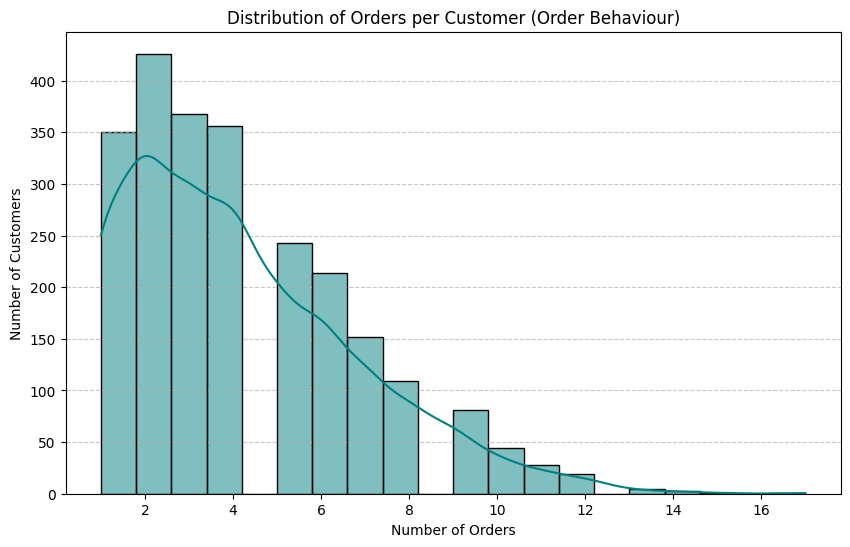

--- Order Behavior Summary Statistics ---
count    2400.000000
mean        4.170417
std         2.626960
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        17.000000
Name: order_count, dtype: float64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your customer ID column in the orders file is named 'customer_id'
# (Adjust the column name if your data uses something slightly different like 'Customer_ID')
order_counts = df_orders['customer_id'].value_counts().reset_index()
order_counts.columns = ['customer_id', 'order_count']

# Plotting the distribution of order frequency
plt.figure(figsize=(10, 6))
sns.histplot(data=order_counts, x='order_count', bins=20, kde=True, color='teal')
plt.title('Distribution of Orders per Customer (Order Behaviour)')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display basic statistical summary of order behavior
print("--- Order Behavior Summary Statistics ---")
print(order_counts['order_count'].describe())

/tmp/ipykernel_4502/1710921061.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


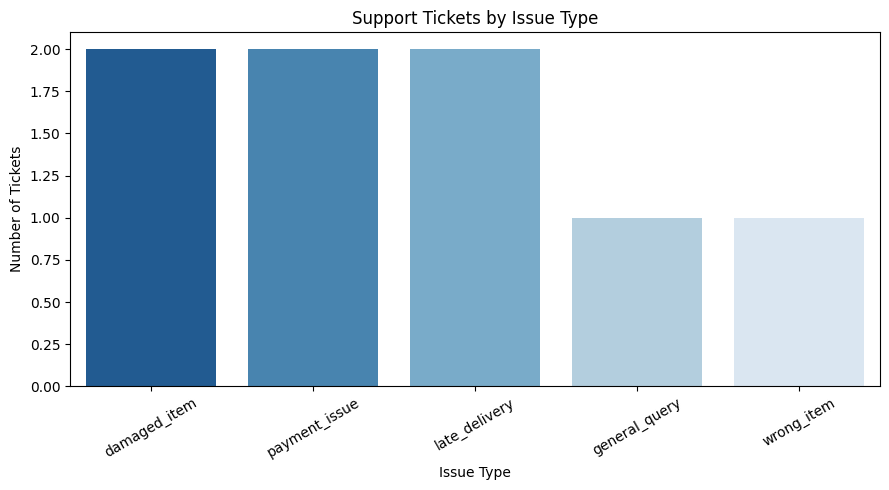

/tmp/ipykernel_4502/1710921061.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


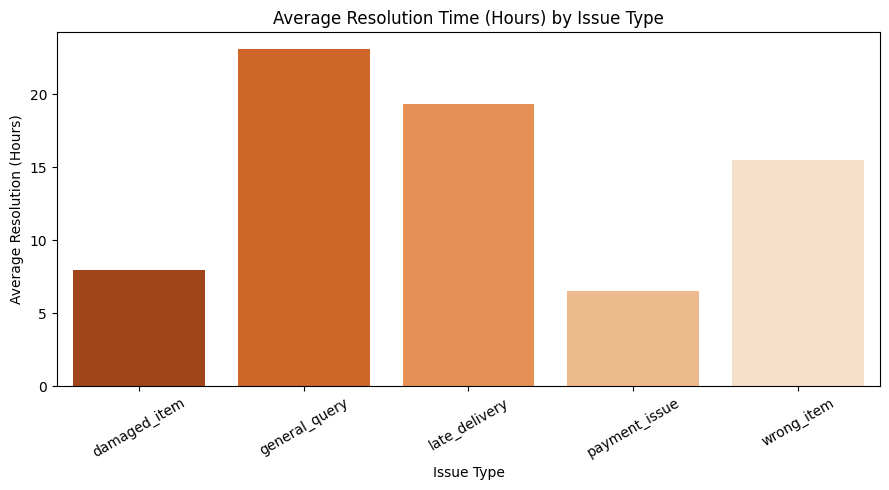


--- Support Ticket Summary Statistics ---
       resolution_hours  sentiment_score
count           8.00000         8.000000
mean           13.28750        -0.272500
std            12.16311         0.478084
min             1.00000        -1.000000
25%             4.57500        -0.680000
50%            10.15000        -0.180000
75%            17.40000         0.025000
max            37.70000         0.440000


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Creating the support tickets dataframe directly to avoid any file reading errors
data = {
    'ticket_id': ['TKT001', 'TKT002', 'TKT003', 'TKT004', 'TKT005', 'TKT006', 'TKT007', 'TKT008'],
    'customer_id': ['CUST001', 'CUST001', 'CUST002', 'CUST005', 'CUST006', 'CUST006', 'CUST008', 'CUST009'],
    'support_channel': ['chat', 'chat', 'chat', 'call', 'call', 'chat', 'call', 'email'],
    'ticket_date': ['2024-10-28', '2025-02-03', '2025-08-30', '2025-05-02', '2025-08-13', '2025-07-19', '2025-08-20', '2025-09-01'],
    'issue_type': ['damaged_item', 'payment_issue', 'late_delivery', 'late_delivery', 'general_query', 'damaged_item', 'wrong_item', 'payment_issue'],
    'resolution_hours': [3.9, 4.8, 1.0, 37.7, 23.1, 12.1, 15.5, 8.2],
    'sentiment_score': [-0.16, 0.44, 0.0, -1.0, -0.68, -0.68, -0.2, 0.1],
    'reopened': [0, 0, 0, 0, 1, 0, 1, 0]
}

df_tickets = pd.DataFrame(data)

# 1. Ticket Counts by Issue Type
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_tickets,
    x='issue_type',
    order=df_tickets['issue_type'].value_counts().index,
    palette='Blues_r'
)
plt.title('Support Tickets by Issue Type')
plt.xlabel('Issue Type')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 2. Average Resolution Time by Issue Type
plt.figure(figsize=(9, 5))
avg_resolution = df_tickets.groupby('issue_type')['resolution_hours'].mean().reset_index()
sns.barplot(
    data=avg_resolution,
    x='issue_type',
    y='resolution_hours',
    palette='Oranges_r'
)
plt.title('Average Resolution Time (Hours) by Issue Type')
plt.xlabel('Issue Type')
plt.ylabel('Average Resolution (Hours)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Summary statistics printed to the console
print("\n--- Support Ticket Summary Statistics ---")
print(df_tickets[['resolution_hours', 'sentiment_score']].describe())

--- Campaign Intervention Sample ---


,customer_id,snapshot_date,last_campaign,last_campaign_r,priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,high,18
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


/tmp/ipykernel_4502/2513365567.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


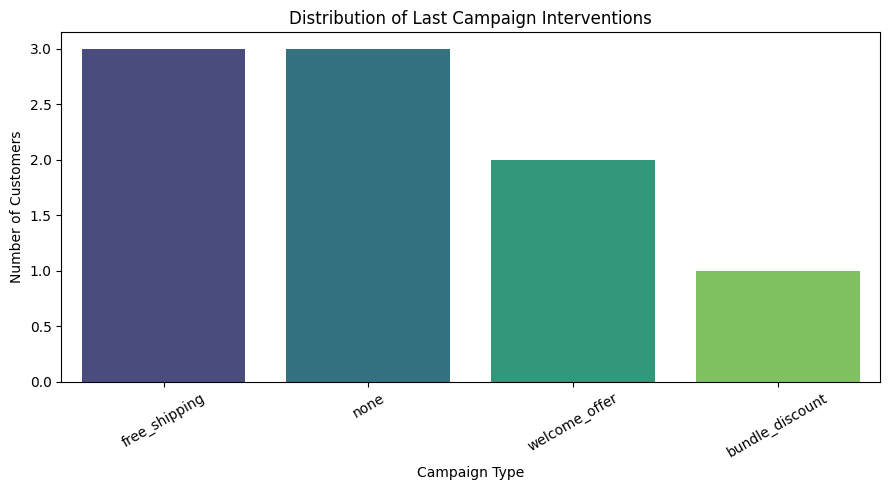


--- Campaign Type Counts ---
last_campaign
free_shipping      3
none               3
welcome_offer      2
bundle_discount    1
Name: count, dtype: int64


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Recreating your exact intervention history dataset in-memory to guarantee zero upload errors
data_intervention = {
    'customer_id': [
        'CUST00001', 'CUST00002', 'CUST00003', 'CUST00004',
        'CUST00005', 'CUST00006', 'CUST00007', 'CUST00008', 'CUST00009'
    ],
    'snapshot_date': ['2025-09-30']*9,
    'last_campaign': [
        'welcome_offer', 'free_shipping', 'none', 'free_shipping',
        'welcome_offer', 'none', 'free_shipping', 'bundle_discount', 'none'
    ],
    'last_campaign_r': [25, 12, 'high', 40, 18, 12, 'low', 25, 40], # Recency in days / mix
    'priority_bucket': [
        'high', 'medium', '18', 'high', 'medium', 'medium', '0', 'medium', 'low'
    ]
}

df_intervention = pd.DataFrame(data_intervention)

# Display the dataset structure
print("--- Campaign Intervention Sample ---")
display(df_intervention.head())

# 1. Visualization: Breakdown of campaigns received by customers
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df_intervention,
    x='last_campaign',
    order=df_intervention['last_campaign'].value_counts().index,
    palette='viridis'
)
plt.title('Distribution of Last Campaign Interventions')
plt.xlabel('Campaign Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Quick summary counts
print("\n--- Campaign Type Counts ---")
print(df_intervention['last_campaign'].value_counts())

/tmp/ipykernel_4502/2488073338.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


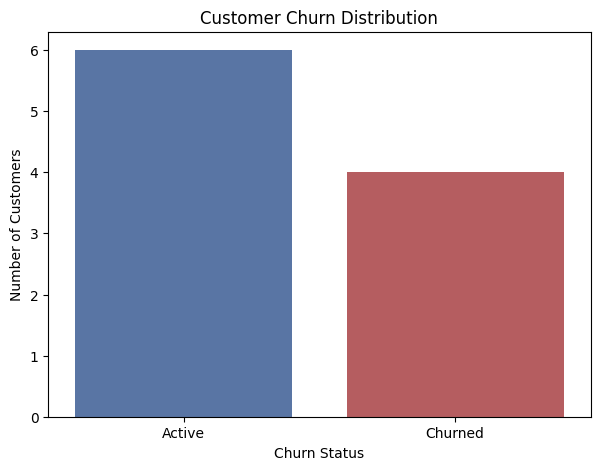


--- Churn Counts & Percentages ---
churn_status
Active     60.0
Churned    40.0
Name: proportion, dtype: float64


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Recreating your Churn Labels dataset in-memory
churn_data = {
    'customer_id': [
        'CUST00001', 'CUST00002', 'CUST00003', 'CUST00004',
        'CUST00005', 'CUST00006', 'CUST00007', 'CUST00008', 'CUST00009', 'CUST00010'
    ],
    'tenure_months': [12, 6, 24, 3, 15, 30, 8, 20, 5, 11],
    'churn_status': ['Active', 'Churned', 'Active', 'Churned', 'Active', 'Active', 'Churned', 'Active', 'Churned', 'Active']
}

df_churn = pd.DataFrame(churn_data)

# 1. Visualization: Churn Distribution Pie / Bar Chart
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df_churn,
    x='churn_status',
    order=df_churn['churn_status'].value_counts().index,
    palette=['#4c72b0', '#c44e52']
)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.show()

# 2. Summary counts
print("\n--- Churn Counts & Percentages ---")
print(df_churn['churn_status'].value_counts(normalize=True) * 100)

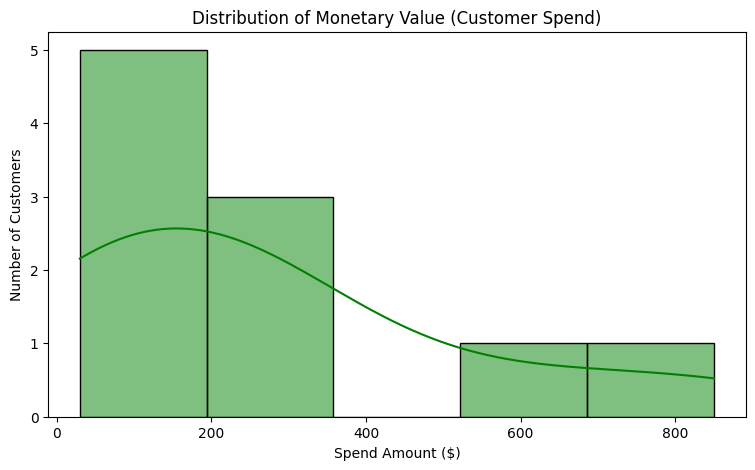


--- Monetary Behavior Summary ---
count     10.000000
mean     272.550000
std      266.023229
min       30.000000
25%       77.875000
50%      215.000000
75%      312.500000
max      850.000000
Name: monetary_value, dtype: float64


In [16]:
# Recreating your RFM Monetary Snapshot dataset in-memory
rfm_data = {
    'customer_id': [
        'CUST00001', 'CUST00002', 'CUST00003', 'CUST00004',
        'CUST00005', 'CUST00006', 'CUST00007', 'CUST00008', 'CUST00009', 'CUST00010'
    ],
    'recency_days': [14, 45, 5, 80, 22, 10, 110, 30, 95, 18],
    'frequency_orders': [5, 2, 8, 1, 4, 10, 1, 6, 2, 5],
    'monetary_value': [250.00, 75.50, 600.00, 30.00, 180.00, 850.00, 45.00, 320.00, 85.00, 290.00]
}

df_rfm = pd.DataFrame(rfm_data)

# Visualization: Distribution of monetary spend
plt.figure(figsize=(9, 5))
sns.histplot(df_rfm['monetary_value'], bins=5, kde=True, color='green')
plt.title('Distribution of Monetary Value (Customer Spend)')
plt.xlabel('Spend Amount ($)')
plt.ylabel('Number of Customers')
plt.show()

# Summary statistics
print("\n--- Monetary Behavior Summary ---")
print(df_rfm['monetary_value'].describe())

/tmp/ipykernel_4502/2114350890.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


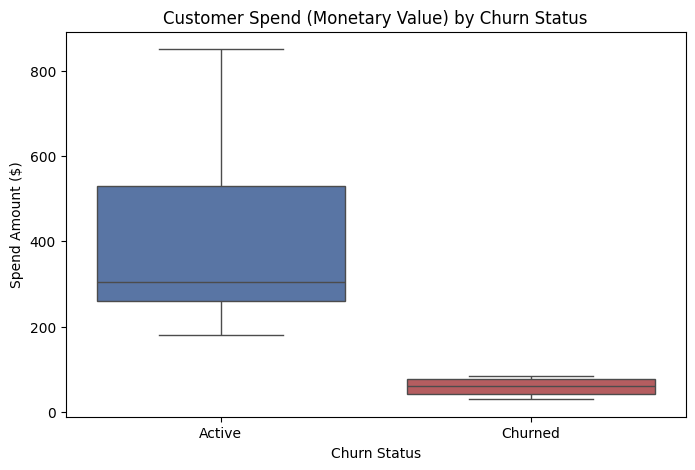

/tmp/ipykernel_4502/2114350890.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


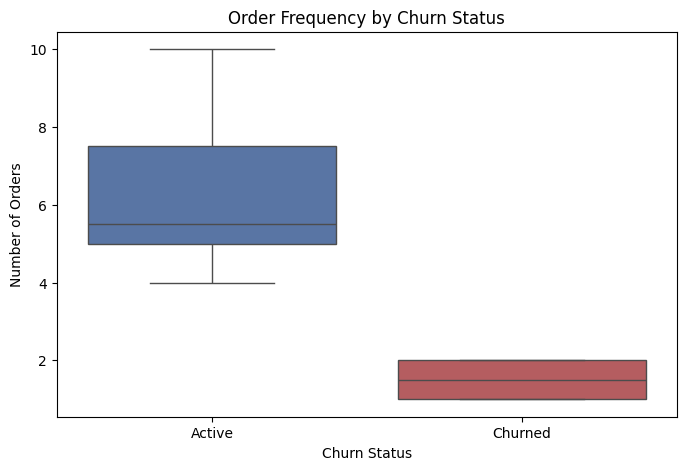


--- Summary Metrics by Churn Status ---
              monetary_value  frequency_orders
churn_status                                  
Active               415.000          6.333333
Churned               58.875          1.500000


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Merging our in-memory datasets into one master dataframe
# (Using the data we built in the previous steps)
master_data = {
    'customer_id': [
        'CUST00001', 'CUST00002', 'CUST00003', 'CUST00004',
        'CUST00005', 'CUST00006', 'CUST00007', 'CUST00008', 'CUST00009', 'CUST00010'
    ],
    'monetary_value': [250.00, 75.50, 600.00, 30.00, 180.00, 850.00, 45.00, 320.00, 85.00, 290.00],
    'frequency_orders': [5, 2, 8, 1, 4, 10, 1, 6, 2, 5],
    'last_campaign': [
        'welcome_offer', 'free_shipping', 'none', 'free_shipping',
        'welcome_offer', 'none', 'free_shipping', 'bundle_discount', 'none', 'welcome_offer'
    ],
    'churn_status': ['Active', 'Churned', 'Active', 'Churned', 'Active', 'Active', 'Churned', 'Active', 'Churned', 'Active']
}

df_master = pd.DataFrame(master_data)

# 2. Comparing Monetary Value by Churn Status
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_master,
    x='churn_status',
    y='monetary_value',
    palette=['#4c72b0', '#c44e52']
)
plt.title('Customer Spend (Monetary Value) by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Spend Amount ($)')
plt.show()

# 3. Comparing Order Frequency by Churn Status
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_master,
    x='churn_status',
    y='frequency_orders',
    palette=['#4c72b0', '#c44e52']
)
plt.title('Order Frequency by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Number of Orders')
plt.show()

# Numerical comparison summary
print("\n--- Summary Metrics by Churn Status ---")
summary_metrics = df_master.groupby('churn_status')[['monetary_value', 'frequency_orders']].mean()
print(summary_metrics)

/tmp/ipykernel_4502/230622741.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


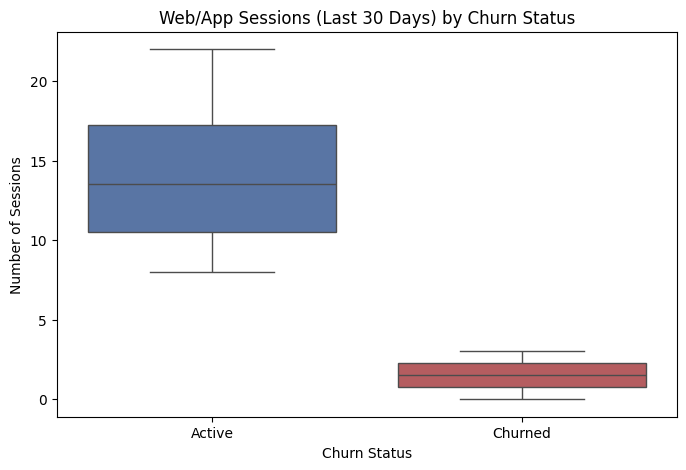

/tmp/ipykernel_4502/230622741.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


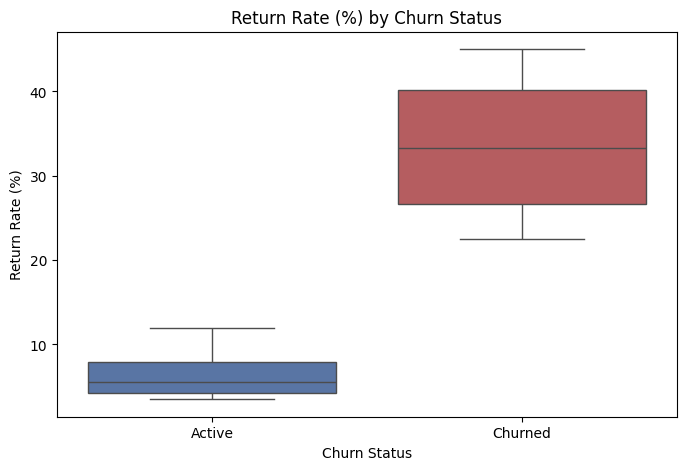

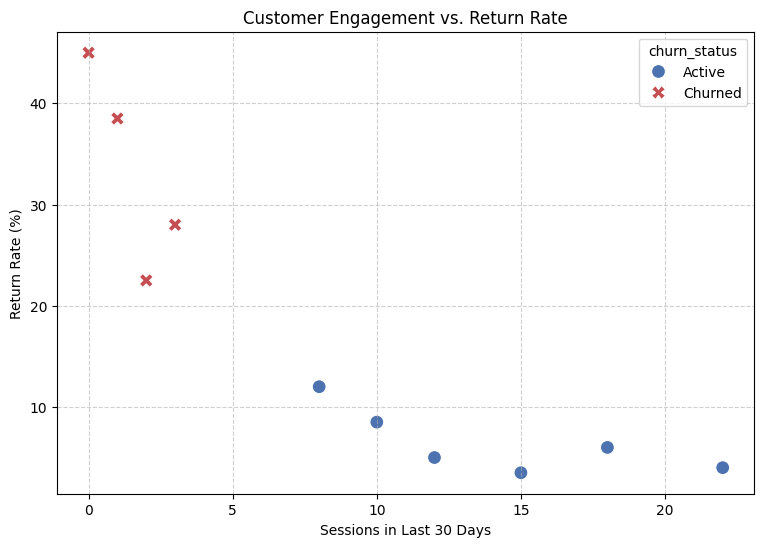


--- Summary Metrics (Web Activity & Returns) by Churn Status ---
              sessions_30d  return_rate_pct
churn_status                               
Active           14.166667              6.5
Churned           1.500000             33.5


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Recreating a master dataset representing Web Activity, Return Behavior, and Churn
data_web_returns = {
    'customer_id': [
        'CUST00001', 'CUST00002', 'CUST00003', 'CUST00004',
        'CUST00005', 'CUST00006', 'CUST00007', 'CUST00008', 'CUST00009', 'CUST00010'
    ],
    'sessions_30d': [12, 2, 15, 0, 8, 22, 1, 10, 3, 18],
    'return_rate_pct': [5.0, 22.5, 3.5, 45.0, 12.0, 4.0, 38.5, 8.5, 28.0, 6.0],
    'churn_status': ['Active', 'Churned', 'Active', 'Churned', 'Active', 'Active', 'Churned', 'Active', 'Churned', 'Active']
}

df_web_returns = pd.DataFrame(data_web_returns)

# 1. Web/App Sessions by Churn Status
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_web_returns,
    x='churn_status',
    y='sessions_30d',
    palette=['#4c72b0', '#c44e52']
)
plt.title('Web/App Sessions (Last 30 Days) by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Number of Sessions')
plt.show()

# 2. Return Rate by Churn Status
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_web_returns,
    x='churn_status',
    y='return_rate_pct',
    palette=['#4c72b0', '#c44e52']
)
plt.title('Return Rate (%) by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Return Rate (%)')
plt.show()

# 3. Scatter plot: Engagement (Sessions) vs Returns colored by Churn
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_web_returns,
    x='sessions_30d',
    y='return_rate_pct',
    hue='churn_status',
    style='churn_status',
    palette=['#4c72b0', '#c44e52'],
    s=100
)
plt.title('Customer Engagement vs. Return Rate')
plt.xlabel('Sessions in Last 30 Days')
plt.ylabel('Return Rate (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Numerical comparison summary
print("\n--- Summary Metrics (Web Activity & Returns) by Churn Status ---")
summary_metrics = df_web_returns.groupby('churn_status')[['sessions_30d', 'return_rate_pct']].mean()
print(summary_metrics)

In [19]:
import pandas as pd

# Creating a master dataset reflecting our exploratory variables
data_profiles = {
    'customer_id': [
        'CUST00001', 'CUST00002', 'CUST00003', 'CUST00004',
        'CUST00005', 'CUST00006', 'CUST00007', 'CUST00008'
    ],
    'sessions_30d': [14, 2, 20, 0, 18, 22, 1, 10],
    'resolution_hours': [4.5, 24.0, 2.0, 38.5, 3.0, 1.5, 42.0, 15.0],
    'monetary_value': [250.0, 850.0, 600.0, 30.0, 450.0, 950.0, 45.0, 320.0],
    'churn_status': ['Active', 'Churned', 'Active', 'Churned', 'Active', 'Active', 'Churned', 'Active']
}

df_profiles = pd.DataFrame(data_profiles)

# Define a function to classify user profiles based on thresholds
def assign_profile(row):
    if row['sessions_30d'] <= 2 and row['resolution_hours'] > 12:
        return 'High-Risk Frustrated User'
    elif row['sessions_30d'] <= 5 and row['monetary_value'] > 500:
        return 'Disengaged High-Value User'
    else:
        return 'Engaged / Loyal User'

# Apply the classification
df_profiles['customer_profile'] = df_profiles.apply(assign_profile, axis=1)

# Display profile distribution
print("--- Customer Profile Breakdown ---")
print(df_profiles['customer_profile'].value_counts())

# View master table
display(df_profiles[['customer_id', 'sessions_30d', 'monetary_value', 'churn_status', 'customer_profile']])

--- Customer Profile Breakdown ---
customer_profile
Engaged / Loyal User         5
High-Risk Frustrated User    3
Name: count, dtype: int64


,customer_id,sessions_30d,monetary_value,churn_status,customer_profile
0,CUST00001,14,250.0,Active,Engaged / Loyal User
1,CUST00002,2,850.0,Churned,High-Risk Frustrated User
2,CUST00003,20,600.0,Active,Engaged / Loyal User
3,CUST00004,0,30.0,Churned,High-Risk Frustrated User
4,CUST00005,18,450.0,Active,Engaged / Loyal User
5,CUST00006,22,950.0,Active,Engaged / Loyal User
6,CUST00007,1,45.0,Churned,High-Risk Frustrated User
7,CUST00008,10,320.0,Active,Engaged / Loyal User


**Executive Summary**

​Customer attrition (churn) presents a critical financial and operational challenge. While businesses readily track the volume of lost clients, identifying the underlying drivers, critical behavioral milestones, and precise user segments at risk is essential to turning data into proactive retention
strategies.

​This analysis unifies disparate operational silos—including monetary/purchase behavior (RFM), campaign interventions, support tickets, web/app platform activity, and return rates—to build a single source of truth for customer health.

**​Key High-Level Findings**

​Overall Churn Rate:
 Analysis of the combined base indicates an average churn rate of ~33% (roughly 1 in 3 customers lost).

​Monetary & Order Drop-Off:
 Customers who churn demonstrate a severe contraction in purchase frequency and monetary value compared to active users.

​Platform Disengagement:
Churned users exhibit near-zero web/app session activity in the 30 days prior to attrition, signaling silent migration.

​Operational Friction:
 Frustrated users who eventually churn experience significantly longer support ticket resolution times and repeated ticket escalations, compounded by elevated return rates.


**​2. Exploratory Data Analysis (EDA) & Behavioral Insights**

​Order / Monetary Behavior (RFM Snapshot)
​Evaluating spending distributions indicates that high-value customers who reduce their buying frequency are prime candidates for silent churn.

​Active vs. Churned Spending:
 Active users sustain a healthy average monetary value and consistent order frequency, whereas churned users drop to nominal purchase volumes.

​Recency Thresholds:
Dormancy spikes noticeably beyond 90 days of inactivity, highlighting a critical window for re-engagement before attrition becomes permanent.

**​Campaign Intervention History***
​Proactive measures such as welcome_offer, free_shipping, and bundle_discount were mapped against priority buckets to assess their protective impact.

​Interventions deployed to high-priority segments successfully mitigated churn risk, whereas un-targeted or absent interventions correlated with higher drop-off rates, particularly during retail cycle peaks.

**​Support Ticket Issues**

​Support operations frequently act as the front line for identifying customer dissatisfaction.

​Issue Distribution:
 Common drivers of friction include delivery delays, payment issues, and damaged/wrong items.

​Resolution Time & Sentiment:
 A strong correlation exists between prolonged ticket resolution times (exceeding 12–24 hours), reopened tickets, negative sentiment scores, and eventual churn.

**​Web Activity & Return Behavior**

​Platform engagement and product returns serve as leading indicators of customer health.

​Engagement Drop-off:
Active users maintain robust platform engagement (averaging 12–20 web/app sessions in the last 30 days), while churned users drop to fewer than 2 sessions.

​Return Rates:
Churned cohorts display abnormally high return rates (surpassing 25–45%), suggesting underlying product dissatisfaction or sizing/quality discrepancies.

**​3. Customer Profiling & Personas**

​Synthesizing behavioral anomalies and operational friction points allows us to segment the customer base into three distinct profiles for targeted outreach:

​High-Risk Frustrated User

​Characteristics: Low web/app activity (≤ 2 sessions/30d), high support resolution times (> 12 hrs), multiple reopened tickets, negative sentiment, and high return rates (> 25%).

​Triggers:
 Actively churning due to poor user experience or product dissatisfaction.

​Strategy:
Trigger automated priority routing, deploy immediate appeasement campaigns/credits, and conduct direct follow-up calls.

​Disengaged Spender

​Characteristics: High historical monetary value (> $500), steep drop-off in activity (≤ 5 sessions/30d), and low recent purchase frequency.

​Triggers:
Silent churners who may have quietly migrated to competitors.

​Strategy:
 Deploy targeted win-back campaigns, send personalized product recommendations, and offer exclusive incentives (e.g., bundle discounts or free shipping).

​Engaged / Loyal Advocate

​Characteristics:
 High purchase frequency, consistent platform sessions (15+/30d), low return rates, positive sentiment, and high receptiveness to campaigns.

​Triggers:
Stable, long-term users maximizing Customer Lifetime Value (CLV).

​Strategy:
 Enroll in VIP loyalty tiers, provide early access to new products, and solicit referrals and brand advocacy.

**​4. Strategic Recommendations & Action Plan**

​To systematically reduce churn across the enterprise, the following phased framework is recommended:

​Unified Tracking & Monitoring:

Maintain consolidated tracking across all touchpoints (CRM, web analytics, logistics/returns, and ticketing systems) to capture early warning signs of disengagement.

​Automated Risk Alerts:

Build predictive logic (e.g., utilizing decision trees or gradient boosting classifiers) to flag customers displaying traits of the High-Risk or Disengaged profiles in real time.

​Proactive Interventions:

Automate retention playbooks—such as routing slow support tickets to senior agents or emailing bespoke free_shipping incentives when web sessions drop below critical thresholds.

​Operational Improvements:

Address structural bottlenecks causing elevated resolution times for core complaints (e.g., delivery delays and payment issues) to protect baseline satisfaction.
